Titanic Dataset Analysis

In [1]:
#Setting Working Directory
import os
os.chdir(r"C:\Users\User\Desktop\pandas\archive")
# Checking directory
os.getcwd()

'C:\\Users\\User\\Desktop\\pandas\\archive'

In [ ]:
import pandas as pd
# Read file
data= pd.read_csv("Titanic-Dataset.csv")

In [7]:
#View first 5 rows of data 
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#View last 5 rows of data
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
#complete information (summary) of your dataset structure
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [23]:
#Checking missing value
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Dataset has 891 rows and 12 columns.
Age = 177 missing values
Cabin = 687 missing values
Embarked = 2 missing values

In [ ]:
#Basic Summary statistics
data.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
#median and mode
# Median values
median_values = data.median(numeric_only=True)

# Mode values
mode_values = data.mode().iloc[0]

print(median_values)
print(mode_values)

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64
PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           24.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Cabin                      B96 B98
Embarked                         S
Name: 0, dtype: object


In [32]:
# Filling missing values in Age using median
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Age'].isnull().sum()

np.int64(0)

In [ ]:
# Drop Cabin column because it has a large number of missing values (approx 77%, which is more then 50% of the entire data )
data = data.drop('Cabin', axis=1)

In [36]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [37]:
# Fill missing values in Embarked using mode (most frequent category)
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['Embarked'].isnull().sum()

np.int64(0)

Mode is used for data handlling because Embarked is a categorical variable, and mean or median cannot be applied to non-numeric data.

In [38]:
# Filter passengers who survived/not survived
data['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

Here 0 represent pessengers who not survived and 1 represents the pessenges who survived
549 not survived 
342 survived

In [39]:
# Survival Percentage
data['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

38.38% of people survived, while 61.61% did not survive.

In [40]:
#survival using sex(Gender)
data.groupby('Sex')['Survived'].value_counts()




Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Females: Survived = 233, Not Survived = 81
Males: Survived = 109, Not Survived = 468

In [41]:
#Survival Percentage(Sex)
data.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [61]:
# Average age by passenger class
data.groupby('Pclass')['Age'].mean()

Pclass
1    36.812130
2    29.765380
3    25.932627
Name: Age, dtype: float64

The average age of passengers in 1st class is 36.81 years.
The average age in 2nd class is 29.77 years.
The average age in 3rd class is 25.93 years.

In [62]:
# Survival rate by embarkation port
data.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

Passengers who embarked from C (Cherbourg) had the highest survival rate (55.36%).
Passengers from Cherbourg (C) were more likely to survive, possibly because more 1st class passengers boarded there.
Passengers from Q (Queenstown) had a moderate survival rate (38.96%).
Passengers from S (Southampton) had the lowest survival rate (33.90%).
Passengers from Southampton (S) had lower survival rates, likely due to a higher proportion of 3rd class passengers.
Therefore, Ports with more wealthy (higher-class) passengers showed higher survival rates.
Embarked indirectly affects survival.

In [63]:
# Pivot table: Survival by Sex and Class
pd.pivot_table(data, values='Survived', index='Sex', columns='Pclass')

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


Females:
1st class → 96.81% survived
2nd class → 92.11% survived
3rd class → 50.00% survived
Males:
1st class → 36.89% survived
2nd class → 15.74% survived
3rd class → 13.54% survived

Gender and class both strongly influenced survival.
Females had a much higher survival rate than males across all classes.
Passengers in higher classes (especially 1st class) had better survival chances.
3rd class males had the lowest survival rate, making them the most vulnerable group.

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\User\AppData\Local\Temp\ipykernel_13724\2685872613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=data,palette='viridis')


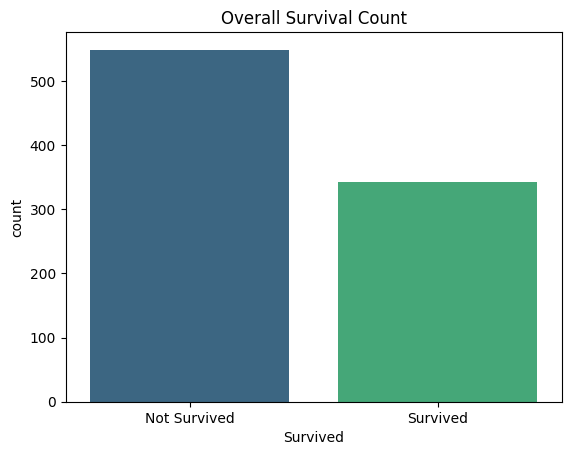

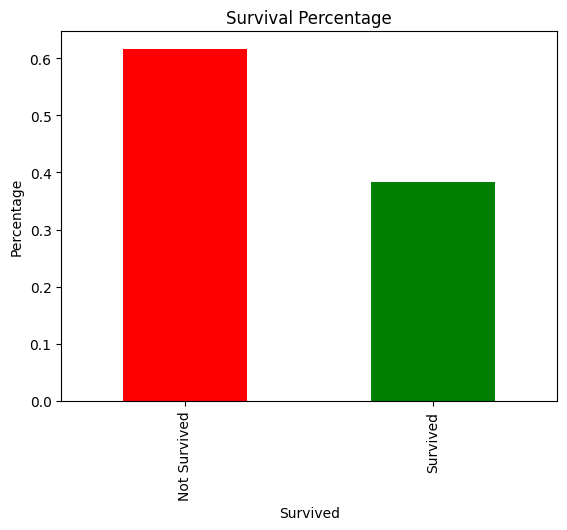

In [48]:
#Visualization of overall Survival Distribution
sns.countplot(x='Survived', data=data,palette='viridis')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.title("Overall Survival Count")
plt.show()

# Survival percentage plot
data['Survived'].value_counts(normalize=True).plot(kind='bar', color=['red', 'green'])

plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.title("Survival Percentage")
plt.ylabel("Percentage")
plt.show()

The analysis shows that around 38% of passengers survived, while 62% did not, indicating a low survival rate and an imbalanced dataset.

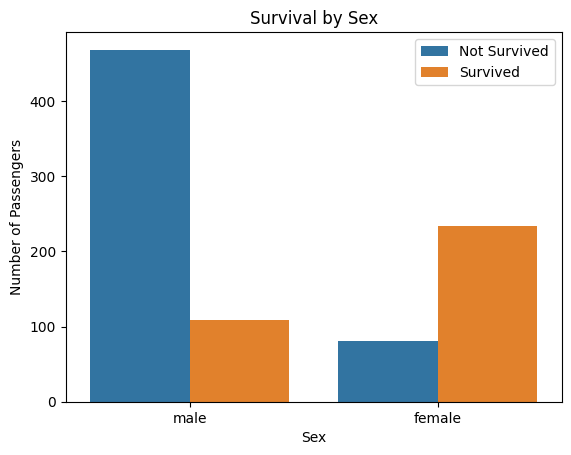

In [52]:


# Survival by gender
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Survival by Sex")
plt.legend(['Not Survived', 'Survived'])
plt.ylabel("Number of Passengers")

plt.show()

The analysis shows that females had a significantly higher survival rate than males, indicating that gender played a crucial role in survival.

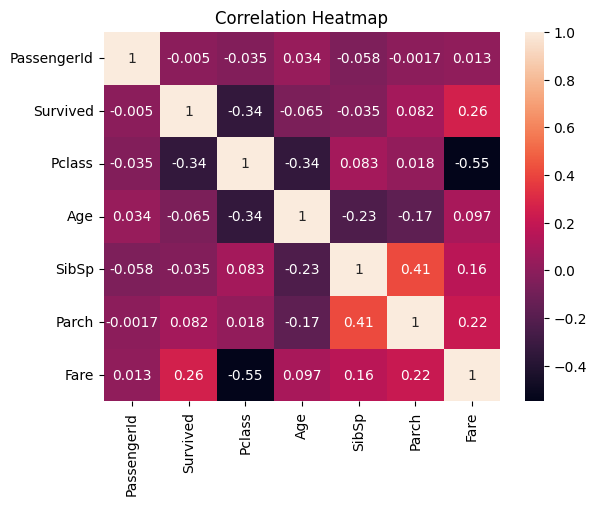

In [ ]:
#Heatmap (correletion between variables)
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Survival vs Pclass (Correlation = -0.34) indicating a moderate negative relationship.
Passengers in 1st class had a higher chance of survival.
Passengers in 3rd class had a lower chance of survival.

Survival vs Fare (Correlation = +0.26) indicating a positive relationship.
Passengers who paid a higher fare had a better chance of survival.
Passengers who paid a lower fare had a lower chance of survival.

Survival vs Age (Correlation = -0.065) indicating a very weak negative relationship.
Survival rates are not strongly dependent on age.
Both younger and older passengers had similar chances of survival.

Pclass vs Fare (Correlation = -0.55) indicating a strong negative relationship.
Passengers in 1st class paid a higher fare.
Passengers in 3rd class paid a lower fare.

SibSp vs Parch (Correlation = +0.41) indicating a moderate positive relationship. 
Passengers traveling with siblings or spouses were also likely to be traveling with parents or children.

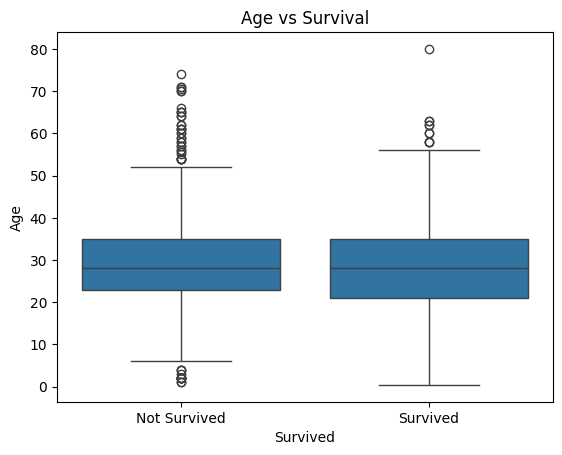

In [ ]:
#Age vs Survival – Boxplot
sns.boxplot(x='Survived', y='Age', data=data)
plt.xticks([0,1], ['Not Survived', 'Survived'])
plt.title("Age vs Survival")
plt.show()

A boxplot is used to compare the distribution of age between survivors and non-survivors by showing the median, spread (quartiles), and outliers clearly.
Age does not have a significant impact on survival, as both survivors and non-survivors have similar age distributions.
There are outliers in both categories (very young and very old passengers). This supports the earlier correlation result (very weak relationship between Age and Survival). Therefore, age alone is not a strong predictor of survival.

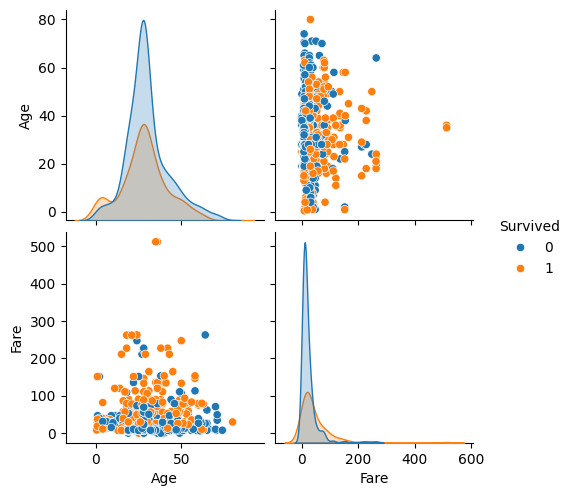

In [ ]:
#Pairplot (Survival(Age, Fair))
sns.pairplot(data[['Age','Fare','Survived']], hue='Survived')

The distribution plots show that Age is similarly distributed for both survivors and non-survivors.
The Fare distribution is skewed, with higher fares more common among survivors.
The scatter plot indicates that passengers who paid higher fares had a greater chance of survival.
There is no clear pattern between Age and Survival, but a visible trend exists between Fare and Survival.

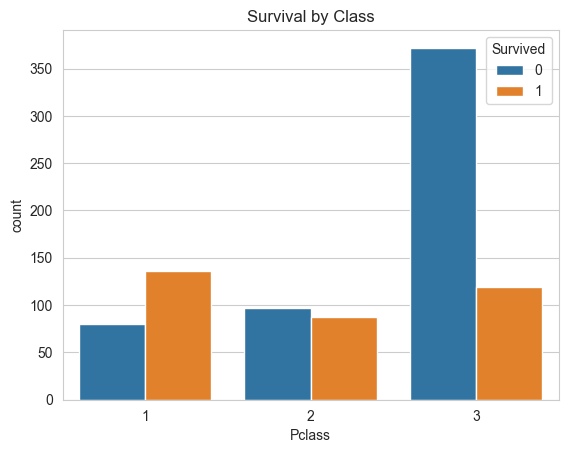

In [60]:
#Survival By Class
sns.countplot(x='Pclass', hue='Survived', data=data)

plt.title("Survival by Class")
plt.show()
sns.set_style("whitegrid")

Passenger class has a strong impact on survival.
Higher-class passengers (1st class) had better chances of survival, while lower-class passengers (3rd class) had lower chances.

In [ ]:
# Total family members (including self)
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['FamilySize'].head()


0    2
1    2
2    1
3    2
4    1
Name: FamilySize, dtype: int64

Passenger 0 → FamilySize = 2 (travelling with 1 family member)
Passenger 1 → FamilySize = 2
Passenger 2 → FamilySize = 1 (travelling alone)
Passenger 3 → FamilySize = 2
Passenger 4 → FamilySize = 1

In [72]:
data['FamilySize'].value_counts()

FamilySize
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

FamilySize = 1 → 537 passengers (majority, traveling alone)
FamilySize = 2 → 161 passengers
FamilySize = 3 → 102 passengers
FamilySize = 4 → 29 passengers
FamilySize = 5–11 → very few passengers

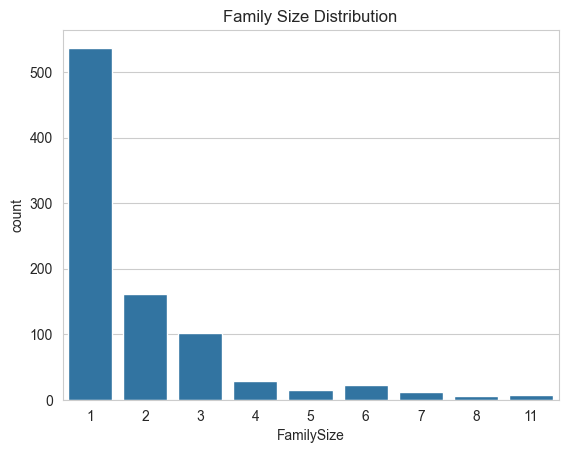

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='FamilySize', data=data)
plt.title("Family Size Distribution")
plt.show()

In [74]:
data.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

FamilySize = 1 → 30.35% survived
FamilySize = 2 → 55.28% survived
FamilySize = 3 → 57.84% survived
FamilySize = 4 → 72.41% survived (highest)
FamilySize = 5–6 → low survival (20%–13.64%)
FamilySize ≥ 7 → very low or 0% survival

In [78]:
# Extract title (Mr, Mrs, Miss, etc.)
data['Title'] = data['Name'].str.extract(' ([A-Za-z]+)\\.', expand=False)
data['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64